In [2]:
%pip install matplotlib 

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

c:\Users\muhammad\ALL THE CODING STUFF\DIGITS CLASSIFIER\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
keras.datasets.mnist.load_data(path="mnist.npz")


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [6]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


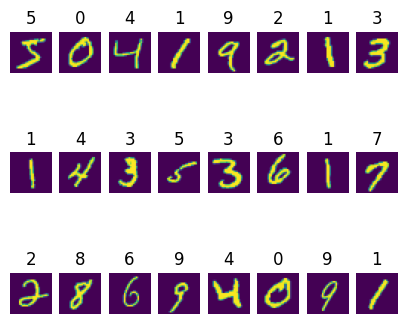

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 6))
img = x_train / 255
for _ in range(24):
    ax = plt.subplot(4,8, _ + 1)
    plt.imshow(img[_].astype("float32"))
    plt.title(y_train[_])
    plt.axis("off")

In [8]:
def residual_block(x, filters, kernel_size=3):
    """ResNet block with two conv layers and a skip connection."""
    shortcut = x
    
    x = tf.keras.layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x



In [32]:
def Classifier(input_shape=(28, 28, 1), num_classes=10):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    x = tf.keras.layers.Conv2D(32, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    # x = layers.MaxPooling2D(2)(x) 
    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.models.Model(inputs, outputs, name="MyResNet")
    return model


In [33]:
model = Classifier()
#model.summary()

In [25]:

# 1. Reload original, clean data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Process IMAGES (x) - Only once!
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Add Channel Dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# 4. LEAVE LABELS (y) ALONE
# Verify: This should print '4', NOT '0.0156'
print(f"Fixed Label: {y_train[2]}") 
print(f"Image Shape: {x_train.shape}")

Fixed Label: 4
Image Shape: (60000, 28, 28, 1)


In [17]:
y_train[2]

np.uint8(4)

In [34]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
tf.config.list_physical_devices('GPU')

[]

In [35]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     
    patience=3,             
    restore_best_weights=True 
)

history = model.fit(
    x_train, y_train,
    epochs=50,              
    batch_size=32,        
    validation_split=0.1,   
    callbacks=[early_stop]  
)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 669s 391ms/step - accuracy: 0.9441 - loss: 0.2076 - val_accuracy: 0.7790 - val_loss: 0.7307
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 932s 539ms/step - accuracy: 0.9801 - loss: 0.0663 - val_accuracy: 0.9810 - val_loss: 0.0673
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 816s 484ms/step - accuracy: 0.9848 - loss: 0.0507 - val_accuracy: 0.9210 - val_loss: 0.2155
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1044s 591ms/step - accuracy: 0.9866 - loss: 0.0434 - val_accuracy: 0.9552 - val_loss: 0.1466
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1296s 768ms/step - accuracy: 0.9881 - loss: 0.0389 - val_accuracy: 0.9642 - val_loss: 0.1107


In [37]:
accuracy = model.evaluate(x_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9769 - loss: 0.0775


In [50]:
model.save("DigitClassifier.h5")

In [52]:
model.save("ResNetDigitClassifier.keras")

In [53]:
model.save_weights("Classifier.weights.h5")